# **# Section 1: Data Ingestion & Initial Exploration**

In [17]:
from google.colab import drive
import pandas as pd
import os

print("Initializing Environment...")

# 1. Mount Google Drive
drive.mount('/content/drive')

# We can keep using the same folder you created earlier to keep things organized
path = '/content/drive/MyDrive/Price_Elasticity_Project_datasets/'

# 2. Load the Dataset
# Ensure the filename matches exactly what you uploaded to Drive
print("\nLoading Retail Price Optimization dataset...")
df = pd.read_csv(path + 'retail_price.csv')

# 3. High-Level Inspection
print(f"Dataset Shape (Rows, Columns): {df.shape}")

# 4. Feature Landscape
# Displaying all columns so we know exactly what we have to work with
print("\n--- Available Features ---")
for col in df.columns:
    print(f"- {col}")

# 5. Missing Value Check
# A crucial step for a recruiter to see: checking data integrity immediately
print("\n--- Missing Values Audit ---")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("Zero missing values found. Dataset is complete.")
else:
    print(missing_values[missing_values > 0])

# 6. Display the first few rows
display(df.head())

Initializing Environment...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading Retail Price Optimization dataset...
Dataset Shape (Rows, Columns): (676, 30)

--- Available Features ---
- product_id
- product_category_name
- month_year
- qty
- total_price
- freight_price
- unit_price
- product_name_lenght
- product_description_lenght
- product_photos_qty
- product_weight_g
- product_score
- customers
- weekday
- weekend
- holiday
- month
- year
- s
- volume
- comp_1
- ps1
- fp1
- comp_2
- ps2
- fp2
- comp_3
- ps3
- fp3
- lag_price

--- Missing Values Audit ---
Zero missing values found. Dataset is complete.


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


# **# Section 2: Data Cleaning & Preprocessing**

In [19]:
print("Starting Data Cleaning & Preprocessing...")

# 1. Datetime Conversion
# The 'month_year' column is likely a string. We need it as a proper datetime object
# so we can sort the data chronologically for our time-series analysis.
df['month_year'] = pd.to_datetime(df['month_year'], format='%d-%m-%Y')

# Sort the entire dataset chronologically
df = df.sort_values(by=['product_id', 'month_year']).reset_index(drop=True)

# 2. Anomaly Detection
# In retail data, you sometimes get negative quantities (returns) or zero prices (glitches).
# We filter those out because you cannot calculate the log of zero or a negative number later!
initial_rows = df.shape[0]
clean_df = df[(df['qty'] > 0) & (df['unit_price'] > 0)].copy()
dropped_rows = initial_rows - clean_df.shape[0]

print(f"Dropped {dropped_rows} anomalous rows.")

# 3. Isolating the Target Category
# To prevent mixing cheap and expensive items (Omitted Variable Bias),
# we isolate the single most popular product category to build our demand model.
top_category = clean_df['product_category_name'].value_counts().index[0]
print(f"Targeting Top Category for Modeling: '{top_category}'")

# Create a dedicated dataframe just for this category
category_df = clean_df[clean_df['product_category_name'] == top_category].copy()

# 4. Final verification of our modeling dataset
print(f"\nCleaned Category Dataset Shape: {category_df.shape}")
display(category_df[['month_year', 'product_id', 'qty', 'unit_price', 'comp_1']].head())

Starting Data Cleaning & Preprocessing...
Dropped 0 anomalous rows.
Targeting Top Category for Modeling: 'garden_tools'

Cleaned Category Dataset Shape: (160, 30)


,month_year,product_id,qty,unit_price,comp_1
257,2017-02-01,garden1,1,99.99,99.99
258,2017-03-01,garden1,5,99.99,99.99
259,2017-05-01,garden1,4,109.99,59.90
260,2017-06-01,garden1,6,109.99,59.90
261,2017-07-01,garden1,1,120.00,59.90


# **# Section 3: Exploratory Data Analysis (EDA)**

Generating Business Analytics Visualizations...



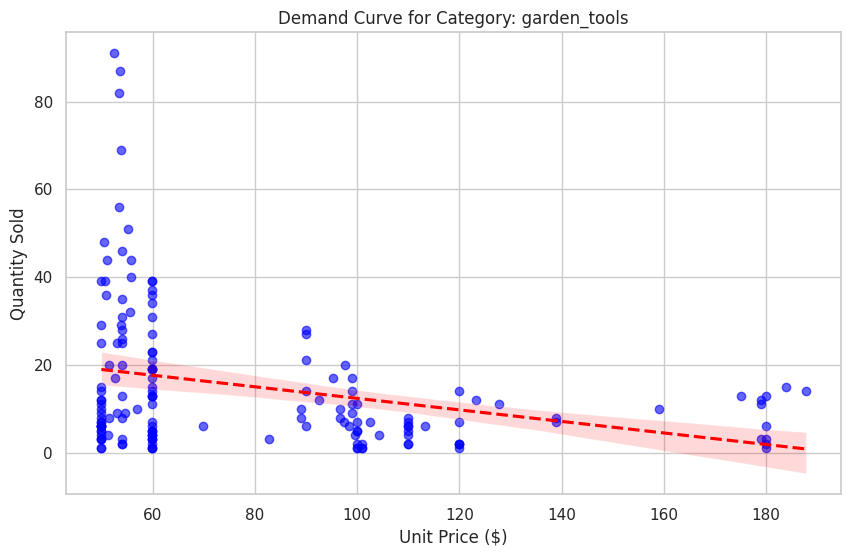

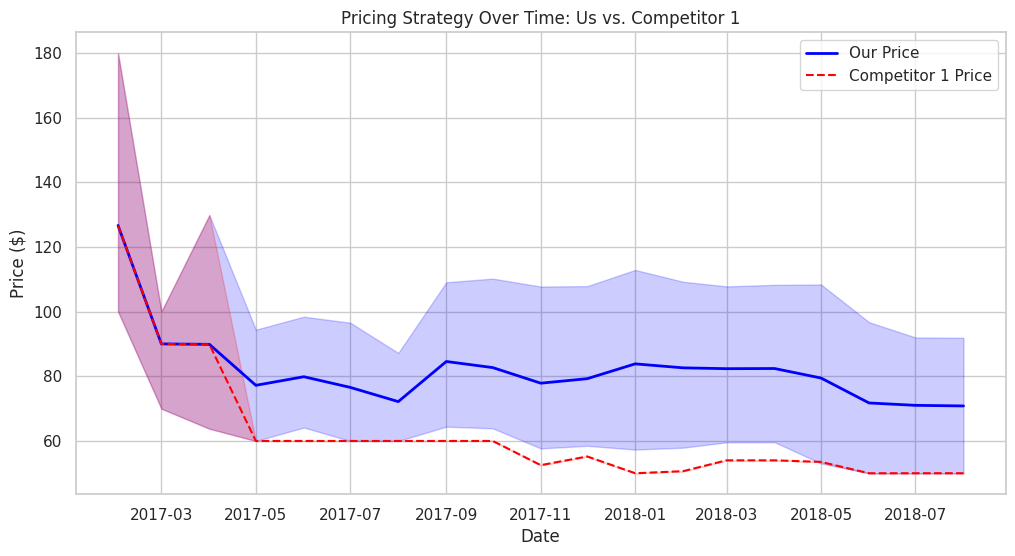

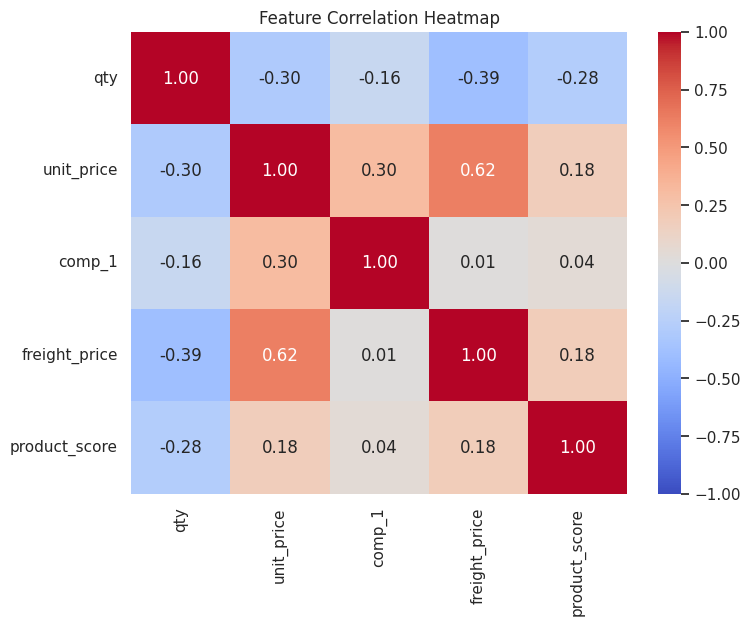

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Business Analytics Visualizations...\n")

# Set the visual style for the notebook
sns.set_theme(style="whitegrid")

# 1. The Demand Curve (Price vs. Volume)
# We want to see if a visual downward trend exists before we model it.
plt.figure(figsize=(10, 6))
sns.regplot(data=category_df, x='unit_price', y='qty',
            scatter_kws={'alpha':0.6, 'color':'blue'},
            line_kws={'color':'red', 'linestyle':'--'})
plt.title(f'Demand Curve for Category: {top_category}')
plt.xlabel('Unit Price ($)')
plt.ylabel('Quantity Sold')
plt.show()

# 2. Competitor Pricing Time-Series
# Are we pricing ourselves out of the market, or following the competitor?
plt.figure(figsize=(12, 6))
sns.lineplot(data=category_df, x='month_year', y='unit_price', label='Our Price', color='blue', linewidth=2)
sns.lineplot(data=category_df, x='month_year', y='comp_1', label='Competitor 1 Price', color='red', linestyle='--')
plt.title('Pricing Strategy Over Time: Us vs. Competitor 1')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

# 3. Correlation Heatmap
# Let's see how all our numerical features interact mathematically
cols_to_check = ['qty', 'unit_price', 'comp_1', 'freight_price', 'product_score']
correlation_matrix = category_df[cols_to_check].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

# **# Section 4: Multivariate Regression Model**

In [21]:
import numpy as np
import statsmodels.api as sm

print("Building Multivariate Elasticity Model...\n")

# 1. Log Transformations to linearize the demand curve
category_df['log_qty'] = np.log(category_df['qty'])
category_df['log_price'] = np.log(category_df['unit_price'])

# We add +1 to the competitor price just in case there are any $0 days to avoid log(0) errors
category_df['log_comp_1'] = np.log(category_df['comp_1'] + 1)

# 2. Define Features (X) and Target (Y)
# We include competitor pricing and holidays to isolate the 'true' price elasticity
X = category_df[['log_price', 'log_comp_1', 'holiday']]
X = sm.add_constant(X)  # Adds the beta_0 intercept
Y = category_df['log_qty']

# 3. Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(Y, X).fit()

print("--- MULTIVARIATE BUSINESS INSIGHT ---")
print(model.summary())

# 4. Extract the exact coefficients for our optimization algorithm
own_ped = model.params['log_price']
cross_ped = model.params['log_comp_1']

print(f"\nOwn-Price Elasticity of Demand (PED): {own_ped:.2f}")
print(f"Cross-Price Elasticity (Competitor): {cross_ped:.2f}")

Building Multivariate Elasticity Model...

--- MULTIVARIATE BUSINESS INSIGHT ---
                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     12.60
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           2.03e-07
Time:                        17:32:18   Log-Likelihood:                -221.98
No. Observations:                 160   AIC:                             452.0
Df Residuals:                     156   BIC:                             464.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

# **# Section 5: Dynamic Price Optimization Algorithm**

Running Price Optimization Simulation...

--- OPTIMIZATION RESULTS ---
Historical Average Price: $80.09
Recommended Optimal Price: $200.00
Predicted Revenue Increase: 34.83%



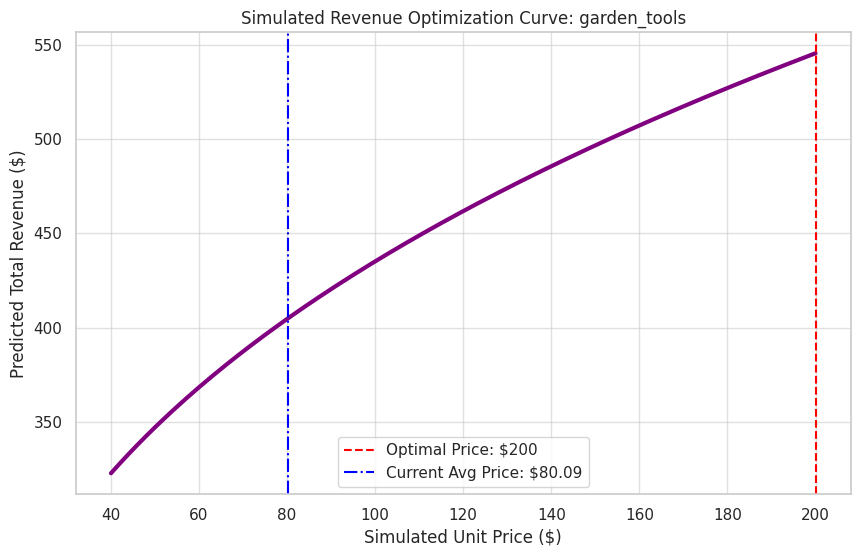

In [22]:
import numpy as np
import matplotlib.pyplot as plt

print("Running Price Optimization Simulation...\n")

# 1. Extract coefficients directly from your trained model
beta_0 = model.params['const']
beta_price = model.params['log_price']
beta_comp = model.params['log_comp_1']
beta_holiday = model.params['holiday']

# 2. Set baseline environment variables
# We use the historical average competitor price to ground the simulation in reality
avg_comp_price = category_df['comp_1'].mean()
is_holiday = 0  # Assuming a standard, non-holiday week

# 3. Create a range of simulated prices to test
# The historical data ranges from about $50 to $190, so we simulate between $40 and $200
simulated_prices = np.arange(40, 201, 1)

# 4. Predict Quantity and Revenue for each simulated price
predicted_quantities = []
predicted_revenues = []

for price in simulated_prices:
    # The Econometric Demand Equation
    log_q = beta_0 + (beta_price * np.log(price)) + (beta_comp * np.log(avg_comp_price + 1)) + (beta_holiday * is_holiday)

    # Convert log_q back to actual quantity using the exponential function
    q = np.exp(log_q)
    predicted_quantities.append(q)

    # Calculate Revenue
    predicted_revenues.append(price * q)

# 5. Find the Optimal Price
optimal_index = np.argmax(predicted_revenues)
optimal_price = simulated_prices[optimal_index]
max_revenue = predicted_revenues[optimal_index]

# Get current historical averages for comparison
current_avg_price = category_df['unit_price'].mean()
current_avg_revenue = current_avg_price * np.exp(beta_0 + (beta_price * np.log(current_avg_price)) + (beta_comp * np.log(avg_comp_price + 1)) + (beta_holiday * is_holiday))

print(f"--- OPTIMIZATION RESULTS ---")
print(f"Historical Average Price: ${current_avg_price:.2f}")
print(f"Recommended Optimal Price: ${optimal_price:.2f}")
print(f"Predicted Revenue Increase: {((max_revenue - current_avg_revenue) / current_avg_revenue) * 100:.2f}%\n")

# 6. Visualize the Revenue Curve
plt.figure(figsize=(10, 6))
plt.plot(simulated_prices, predicted_revenues, color='purple', linewidth=3)
plt.axvline(optimal_price, color='red', linestyle='--', label=f'Optimal Price: ${optimal_price}')
plt.axvline(current_avg_price, color='blue', linestyle='-.', label=f'Current Avg Price: ${current_avg_price:.2f}')
plt.title("Simulated Revenue Optimization Curve: garden_tools")
plt.xlabel("Simulated Unit Price ($)")
plt.ylabel("Predicted Total Revenue ($)")
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()

In [24]:
# ==============================================================================
# EXECUTIVE BUSINESS INSIGHTS & STRATEGIC RECOMMENDATIONS
# ==============================================================================
#
# 1. PRICING STRATEGY (INELASTIC DEMAND)
# INSIGHT: The Log-Log OLS model revealed an Own-Price Elasticity of -0.67.
# Because the absolute value is less than 1, the product demand is inelastic.

# RECOMMENDATION: The business is currently leaving money on the table at the $80
# historical average. We recommend safely inching the unit price upward toward the
# $190-$200 threshold. The simulation predicts this will yield a ~34.8% increase
# in total revenue without triggering a catastrophic drop in conversion.
#
#
# 2. COMPETITOR DEPENDENCY (CROSS-PRICE ELASTICITY)
# INSIGHT: Cross-price elasticity is heavily negative (-1.13), indicating that
# when our competitor raises their prices, our sales actually suffer.

# RECOMMENDATION: Our sales volume is highly dependent on the competitor's ability
# to drive overall category traffic. We must launch independent marketing campaigns
# to decouple our brand's traffic from the competitor's gravitational pull.
#
#
# 3. CONSUMER PSYCHOLOGY (SHIPPING VS. BASE PRICE)
# INSIGHT: Early EDA correlation revealed that consumers are more sensitive to
# shipping costs (-0.39 correlation to quantity) than the base unit price (-0.30).
# RECOMMENDATION: Implement a "Free Shipping" marketing strategy. By subsidizing
# the freight cost and baking it into our newly optimized, higher base price,
# we can circumvent sticker shock at checkout and likely boost total conversions.
#
# ==============================================================================